# YOLO Data Augmentation

## Purpose
This notebook trains and evaluates a YOLO model using an already-augmented dataset

The dataset is expected to already be in YOLO format. This notebook does **NOT** create new augmentations, but instead prepares an augmented dataset for YOLO training

##What this notebook does
1. Mounts Google Drive so the augmented dataset ZIP file and base model can be accessed.
2. Extracts the augmented dataset into the Colab runtime.
3. Reorganizes the dataset into the folder structure expected by YOLO.
4. Creates a `data.yaml` configuration file for a single class called `unhealthy_leaf`.
5. Trains a YOLO model using a saved base model from Google Drive.
6. Validates the trained model and prints key metrics.
7. Plots validation metrics across epochs.
8. Displays the confusion matrix from the training run.

## How to use this notebook
1. Make sure the augmented dataset zip file is in google drive
2. Confirm that the zip file path is correct:

   '''python
   zip_path = "/content/drive/Mydrive/augmented1.zip
   '''

3. Confirm that the extracted dataset has this structure:

   ```text
   augmented1/
   ├── train/
   │   ├── images/
   │   └── labels/
   └── valid/
       ├── images/
       └── labels/
   ```

4. Confirm that the base YOLO model exists at this path:

   ```python
   /content/drive/MyDrive/BaseModel.pt
   ```

5. Run the notebook from top to bottom.
6. Review the results saved under:

   ```python
   /content/yolo_runs/yolov8_model_training
   ```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os
import shutil

zip_path = "/content/drive/MyDrive/augmented1.zip" #change path if needed
extract_dir = "/content/dataset_raw"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extracted to:", extract_dir)
print("Top-level contents:", os.listdir(extract_dir))

Extracted to: /content/dataset_raw
Top-level contents: ['__MACOSX', 'augmented1']


In [ ]:
import os
import shutil
from pathlib import Path

base_input_dir = Path("/content/dataset_raw/augmented1")
output_root = Path("/content/yolo_dataset")

if output_root.exists():
    shutil.rmtree(output_root)
output_root.mkdir(parents=True, exist_ok=True)

splits = {
    "train": {"images_src": base_input_dir / "train" / "images", "labels_src": base_input_dir / "train" / "labels"},
    "val":   {"images_src": base_input_dir / "valid" / "images", "labels_src": base_input_dir / "valid" / "labels"},
}

# Function to copy images and labels for a given split
def copy_dataset_split(split_name, images_src_dir, labels_src_dir, base_dst_dir):
    print(f"Preparing '{split_name}' split...")
    images_dst_dir = base_dst_dir / "images" / split_name
    labels_dst_dir = base_dst_dir / "labels" / split_name

    images_dst_dir.mkdir(parents=True, exist_ok=True)
    labels_dst_dir.mkdir(parents=True, exist_ok=True)

    # Copy images
    for img_path in images_src_dir.glob("*.*"):
        shutil.copy(img_path, images_dst_dir / img_path.name)
    print(f"Copied {len(list(images_src_dir.glob('*.*')))} images to {images_dst_dir}")

    # Copy labels
    for label_path in labels_src_dir.glob("*.txt"):
        shutil.copy(label_path, labels_dst_dir / label_path.name)
    print(f"Copied {len(list(labels_src_dir.glob('*.txt')))} labels to {labels_dst_dir}")
    print(f"'{split_name}' split prepared.")

# Iterate through splits and copy data
for split_name, paths in splits.items():
    # Adjust destination split name for 'val' to match YOLO's 'val' convention
    dest_split_name = "val" if split_name == "val" else split_name
    copy_dataset_split(dest_split_name, paths["images_src"], paths["labels_src"], output_root)

print(f"\nSuccessfully prepared dataset at {output_root} with train, val, and test splits.")


Preparing 'train' split...
Copied 606 images to /content/yolo_dataset/images/train
Copied 606 labels to /content/yolo_dataset/labels/train
'train' split prepared.
Preparing 'val' split...
Copied 39 images to /content/yolo_dataset/images/val
Copied 39 labels to /content/yolo_dataset/labels/val
'val' split prepared.

Successfully prepared dataset at /content/yolo_dataset with train, val, and test splits.


In [ ]:
from pathlib import Path

class_names = ["unhealthy_leaf"]
output_root = Path("/content/yolo_dataset")

# Note: test is listed for completeness, but this notebook only prepares train and val folders.
yaml_text = f"""
path: {output_root}
train: images/train
val: images/val
test: images/test

names:
  0: {class_names[0]}
""".strip()

with open(output_root / "data.yaml", "w") as f:
    f.write(yaml_text)

print(f"Created {output_root / 'data.yaml'}")

Created /content/yolo_dataset/data.yaml


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from pathlib import Path

output_root = Path("/content/yolo_dataset") # Ensure output_root is defined for this cell

data_yaml = output_root / "data.yaml"

# Load the starting model weights from Google Drive.
# Change this path if the base model is stored somewhere else.
model = YOLO("/content/drive/MyDrive/BaseModel.pt")

# Train the model on the augmented dataset.
# Adjust epochs, patience, image size, or batch size if training is too slow or unstable.
results = model.train(
    data=str(data_yaml),
    epochs=100,
    patience=15,
    imgsz=1280,
    batch=8,
    cache=True,
    project="/content/yolo_runs",
    name="yolov8_model_training"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False,

In [ ]:
# Load the best weights saved during training.
model = YOLO("/content/yolo_runs/yolov8_model_training/weights/best.pt")
metrics = model.val(data="/content/dataset_raw/augmented1/data.yaml")

print("Fold_1metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5195.7±1833.5 MB/s, size: 113.4 KB)
val: Scanning /content/dataset_raw/augmented1/valid/labels... 39 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 4.3Kit/s 0.0s
val: New cache created: /content/dataset_raw/augmented1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.0it/s 1.0s
                   all         39         99      0.402      0.242      0.249     0.0896
Speed: 4.8ms preprocess, 12.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val-3
Fold_1metrics
Precision: 0.40168763982523514
Recall: 0.24242424242424243
mAP50: 0.24899020736032706
mAP50-95: 0.08962270247922982


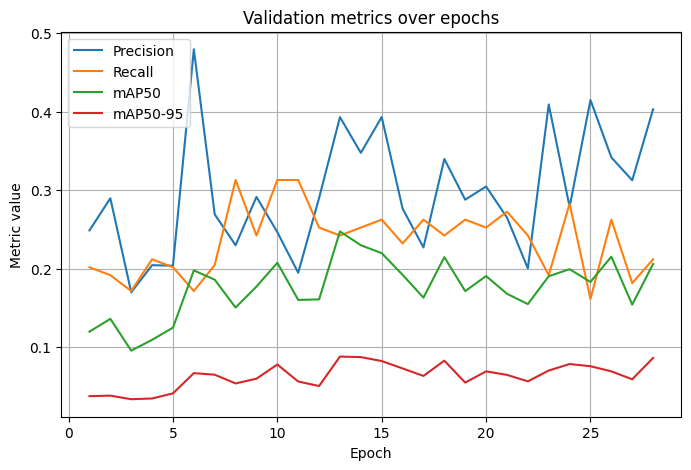

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ultralytics saves training metrics to results.csv.
df = pd.read_csv("/content/yolo_runs/yolov8_model_training/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

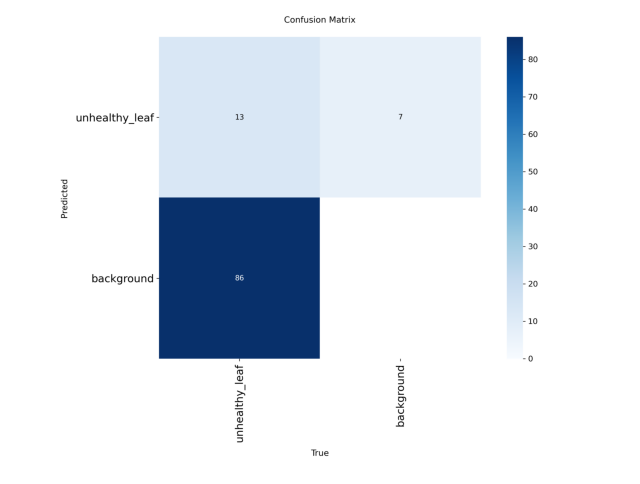

In [ ]:
from PIL import Image

# Display the confusion matrix image generated by the YOLO training run.
img = Image.open("/content/yolo_runs/yolov8_model_training/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()